# BRFSS 2015 Diabetes Health Indicators — Predictive Models

**Authors:** Wolfgang Klein, Sydney Bailey, Harvey Luna, Nashita Kandaker
**Data:** `diabetes_012_health_indicators_BRFSS2015.csv`, target collapsed to binary
(prediabetes and diabetes both coded 1)

## Intro

In [Lab 1](https://lone-wolfgang.github.io/brfss2015-diabetes-eda/#Lab1/WolfgangKlein)
we explored a dataset that links health, demographics, and income to a diabetes
diagnosis. See Lab 1 for the full data review.

The goal here is to build two predictive models.

## Models

We train two model families: logistic regression and support vector machines (SVM).

**Logistic regression** is fast to fit. If its assumptions hold, the coefficients
are easy to interpret. Non-linear effects can be added with squared terms and
interactions.

**SVM** is a non-parametric model. It learns a boundary between the classes. The
main choice is the kernel: linear (fast), polynomial (curved boundaries), or RBF
(most flexible, slowest).

Lab 1 supported logistic regression, and a first model reached an AUC of 0.814.
We expect logistic regression to perform about as well as the SVMs. RBF is slow,
so it will first be tried on a subset.

This notebook currently covers **logistic regression only**.

## Metrics

The model flags people at risk of diabetes so they can be referred for screening.
Missing a case is costly, and so is an unneeded referral.

- **Recall**: share of true cases we flag.
- **Precision**: share of flags that are true cases.

Recall matters more, so models are compared on **F2**, which weights recall above
precision.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             fbeta_score, confusion_matrix)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

PALETTE = {
    "ink":    "#22303c",
    "grid":   "#dfe4e8",
    "neg":    "#8fa3b0",   # reference / unexposed
    "pos":    "#b5442e",   # diabetes / elevated
    "prot":   "#2f6f6a",   # protective direction
    "accent": "#c98a1b",
}
SEQ = sns.blend_palette(["#f5f2ea", "#d8b26a", "#b5442e", "#5c1d13"], as_cmap=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10.5, "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.7,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": PALETTE["ink"], "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"], "ytick.color": PALETTE["ink"],
    "legend.frameon": False, "figure.facecolor": "white",
})

SEED = 0
print("pandas", pd.__version__, "| numpy", np.__version__, "| statsmodels", sm.__version__)

pandas 3.0.2 | numpy 2.4.4 | statsmodels 0.15.0


In [2]:
import os

PATH = "../data/diabetes_012_health_indicators_BRFSS2015.csv"
assert os.path.exists(PATH), f"Dataset not found at {PATH}. See README for setup."

raw = pd.read_csv(PATH)
raw["Diabetes_binary"] = (raw["Diabetes_012"] > 0).astype(int)
raw = raw.drop(columns="Diabetes_012")

TARGET = "Diabetes_binary"
print(f"shape   : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"target  : {TARGET}, prevalence {100*raw[TARGET].mean():.2f}%")

shape   : 253,680 rows x 22 columns
target  : Diabetes_binary, prevalence 15.76%


## 1. Feature Considerations

Three changes, all from Lab 1:

- **Drop `CholCheck`.** Lab 1 §11 showed it tracks access to a doctor, not disease.
- **Winsorize BMI at 70.** Values above 70 are a data artifact.
- **Add squared terms for Age and Income.** Both curves bend. Each is centered
  before squaring.

In [3]:
df = raw.drop(columns="CholCheck").copy()
df["BMI"] = np.minimum(df["BMI"], 70)

for col in ["Age", "Income"]:
    df[col] = df[col] - df[col].mean()
    df[f"{col}_sq"] = df[col] ** 2

FEATURES = [c for c in df.columns if c != TARGET]
print(f"{len(FEATURES)} features:", ", ".join(FEATURES))

22 features: HighBP, HighChol, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income, Age_sq, Income_sq


## 2. Splits

The data is split 70 / 15 / 15, stratified on the target.

- **train (70%)**: fits the model. For the SVMs it will also be used for tuning with
  5-fold CV.
- **validation (15%)**: picks the decision threshold.
- **test (15%)**: final, unbiased score at the chosen threshold.

In [4]:
X, y = df[FEATURES], df[TARGET]

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

display(pd.DataFrame({
    "rows":         [len(y_train), len(y_val), len(y_test)],
    "share %":      [100*len(y_train)/len(y), 100*len(y_val)/len(y), 100*len(y_test)/len(y)],
    "prevalence %": [100*y_train.mean(), 100*y_val.mean(), 100*y_test.mean()],
}, index=["train", "validation", "test"]).round(2))

,rows,share %,prevalence %
train,177576,70.0000,15.7600
validation,38052,15.0000,15.7600
test,38052,15.0000,15.7600


## 3. Logistic Regression

The model is fit on the training set. The table shows each coefficient, its odds
ratio, and a 95% confidence interval.

In [5]:
logit = sm.Logit(y_train, sm.add_constant(X_train)).fit(disp=0)

ci = logit.conf_int()
params = pd.DataFrame({
    "coef":       logit.params,
    "ci_low":     ci[0],
    "ci_high":    ci[1],
    "odds_ratio": np.exp(logit.params),
    "or_low":     np.exp(ci[0]),
    "or_high":    np.exp(ci[1]),
    "p_value":    logit.pvalues,
})
display(params.round(4))
print(f"McFadden pseudo-R2: {logit.prsquared:.4f}")

,coef,ci_low,ci_high,odds_ratio,or_low,or_high,p_value
const,-5.5032,-5.6442,-5.3623,0.0041,0.0035,0.0047,0.0000
HighBP,0.6953,0.6630,0.7277,2.0044,1.9405,2.0704,0.0000
HighChol,0.5714,0.5412,0.6016,1.7708,1.7180,1.8251,0.0000
BMI,0.0647,0.0626,0.0669,1.0669,1.0646,1.0692,0.0000
Smoker,-0.0295,-0.0591,0.0001,0.9709,0.9426,1.0001,0.0504
Stroke,0.1153,0.0577,0.1729,1.1222,1.0593,1.1887,0.0001
HeartDiseaseorAttack,0.2175,0.1767,0.2584,1.2430,1.1933,1.2948,0.0000
PhysActivity,-0.0472,-0.0796,-0.0147,0.9539,0.9235,0.9854,0.0044
Fruits,-0.0446,-0.0752,-0.0139,0.9564,0.9275,0.9862,0.0044
Veggies,-0.0463,-0.0819,-0.0106,0.9548,0.9213,0.9895,0.0110


McFadden pseudo-R2: 0.2067


Odds ratios above 1 raise the risk, and below 1 lower it. For binary features, the
odds ratio compares a 1 to a 0. For the others, it is the change per one unit.

## 4. Threshold Tuning

Left: the ROC curve on the validation set. Right: precision, recall, and F2 at each
threshold. The threshold with the highest F2 is marked.

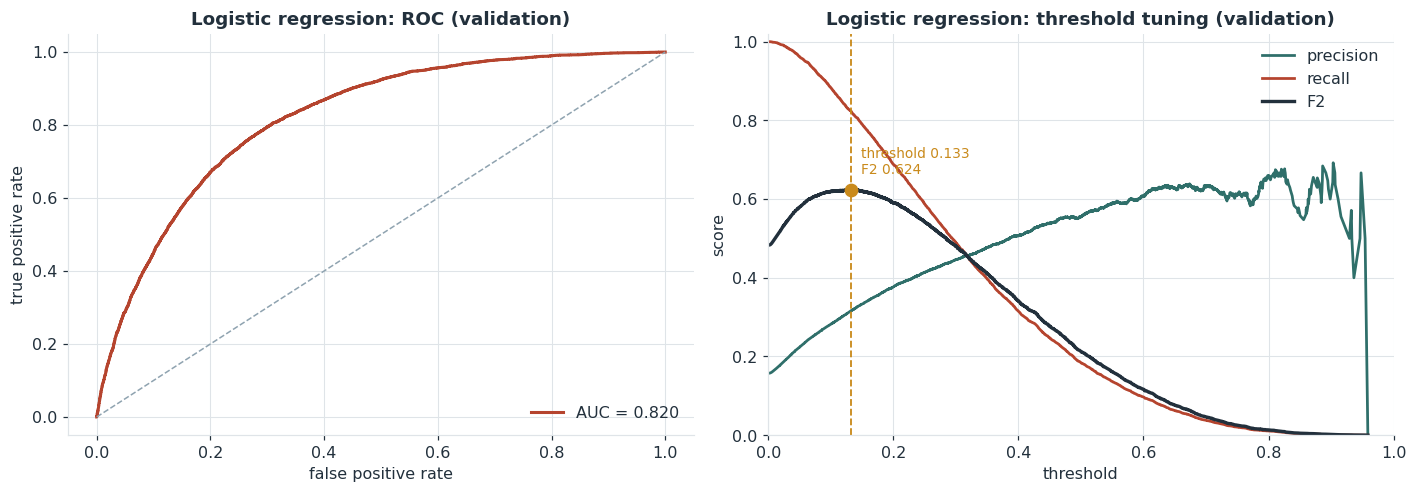

best threshold 0.133: precision 0.317, recall 0.823, F2 0.624


In [6]:
def f2_curve(y_true, p):
    """Precision, recall, and F2 at every threshold."""
    prec, rec, thr = precision_recall_curve(y_true, p)
    prec, rec = prec[:-1], rec[:-1]
    f2 = np.where(prec + rec > 0, 5 * prec * rec / (4 * prec + rec), 0)
    return thr, prec, rec, f2


def tune_plot(name, p_val):
    fpr, tpr, _ = roc_curve(y_val, p_val)
    auc = roc_auc_score(y_val, p_val)
    thr, prec, rec, f2 = f2_curve(y_val, p_val)
    i = int(np.argmax(f2))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

    ax = axes[0]
    ax.plot(fpr, tpr, color=PALETTE["pos"], lw=2, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], color=PALETTE["neg"], ls="--", lw=1)
    ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
    ax.set_title(f"{name}: ROC (validation)"); ax.legend(loc="lower right")

    ax = axes[1]
    ax.plot(thr, prec, color=PALETTE["prot"], lw=1.8, label="precision")
    ax.plot(thr, rec,  color=PALETTE["pos"],  lw=1.8, label="recall")
    ax.plot(thr, f2,   color=PALETTE["ink"],  lw=2.2, label="F2")
    ax.axvline(thr[i], color=PALETTE["accent"], ls="--", lw=1.2)
    ax.plot(thr[i], f2[i], "o", color=PALETTE["accent"], ms=8)
    ax.text(thr[i] + .015, f2[i] + .04, f"threshold {thr[i]:.3f}\nF2 {f2[i]:.3f}",
            color=PALETTE["accent"], fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("threshold"); ax.set_ylabel("score")
    ax.set_title(f"{name}: threshold tuning (validation)"); ax.legend(loc="upper right")

    plt.tight_layout(); plt.show()
    print(f"best threshold {thr[i]:.3f}: precision {prec[i]:.3f}, recall {rec[i]:.3f}, F2 {f2[i]:.3f}")
    return thr[i], f2[i]


p_val_lr = logit.predict(sm.add_constant(X_val))
thr_lr, val_f2_lr = tune_plot("Logistic regression", p_val_lr)

## 5. Results

Each model is scored on the test set at its tuned threshold.

In [7]:
p_test_lr = logit.predict(sm.add_constant(X_test))

RESULTS = {
    "Logistic regression": dict(threshold=thr_lr, val_f2=val_f2_lr, p_test=p_test_lr),
}

results = pd.DataFrame([
    {"Model": name,
     "Validation F2": r["val_f2"],
     "Test F2": fbeta_score(y_test, r["p_test"] >= r["threshold"], beta=2)}
    for name, r in RESULTS.items()
]).sort_values("Validation F2", ascending=False)
results.insert(0, "Rank", range(1, len(results) + 1))
display(results.set_index("Rank").round(4))

,Model,Validation F2,Test F2
Rank,,,
1,Logistic regression,0.6236,0.6224


Confusion matrix for the best model on the test set.

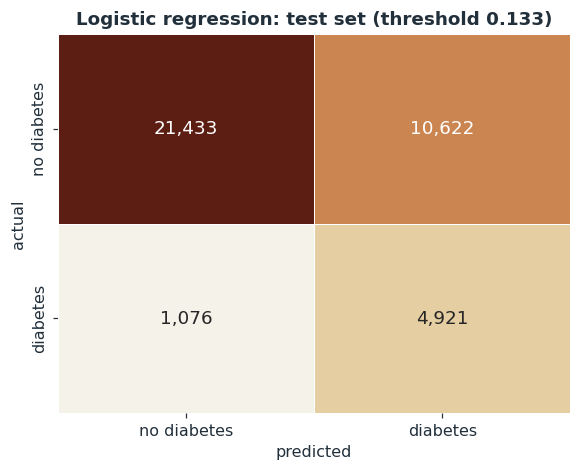

recall    : 0.821  (4,921 of 5,997 cases flagged)
precision : 0.317  (4,921 of 15,543 flags are cases)


In [8]:
best = results.iloc[0]["Model"]
r = RESULTS[best]
cm = confusion_matrix(y_test, r["p_test"] >= r["threshold"])

fig, ax = plt.subplots(figsize=(5.4, 4.4))
sns.heatmap(cm, annot=True, fmt=",d", cmap=SEQ, cbar=False, ax=ax,
            linewidths=.6, linecolor="white", annot_kws={"fontsize": 12},
            xticklabels=["no diabetes", "diabetes"], yticklabels=["no diabetes", "diabetes"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title(f"{best}: test set (threshold {r['threshold']:.3f})")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"recall    : {tp/(tp+fn):.3f}  ({tp:,} of {tp+fn:,} cases flagged)")
print(f"precision : {tp/(tp+fp):.3f}  ({tp:,} of {tp+fp:,} flags are cases)")